# Part 3 — The Upgrade Shop: Modernizing the Transformer

## Think of it as a tune-up garage 🔧

In Parts 1 and 2 we built a working car — a basic Transformer that actually runs. It drives, but it's the 2017 model. Part 3 is the **upgrade shop**: we keep the same car and the same layout, but swap each part for the modern version that today's real LLMs (Llama, Mistral, Phi) use. Lighter, faster, and able to go much further on a tank.

The car still has the same parts in the same order — we just replace each one with its upgraded model:

| The part | Old (Parts 1-2) | Upgraded (Part 3) | Everyday image |
|---|---|---|---|
| keep signals balanced | LayerNorm | **RMSNorm** (3.1) | a simpler audio leveler |
| tell words their position | add a position vector | **RoPE** (3.2) | a clock-hand dial |
| each word "thinks" | plain FFN | **SwiGLU** (3.3) | a smart dimmer switch |
| remember what's been read | recompute every time | **KV cache** (3.4) | taking notes |
| share that memory | every reader its own copy | **GQA** (3.5) | sharing one set of notes |

**What this part is:** the same model from Part 1, with every part replaced by the modern one — then bolted back together (3.6) into a full model you can actually run (3.7).

**What you should know going in:**
- Part 1 (attention, the feed-forward step, LayerNorm, residual shortcuts) is fresh
- Part 2 (the training loop and generating text one word at a time) is fresh

We follow one tiny sentence — `"I love deep learning"` (4 words) — through every upgrade, with small numbers so everything fits on screen.


## The Map

The car's layout never changes — same parts, same order. That's the diagram below, and you'll see it at the top of every section with the part we're upgrading lit up in green and the rest greyed out, so you always know which part is on the lift.

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#e8e8e8,stroke:#bbb,color:#777
    style attn fill:#e8e8e8,stroke:#bbb,color:#777
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style rms2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

The order is exactly Part 1's block: keep signals balanced (**RMSNorm**) → let words look at each other (**attention**, now with RoPE + shared notes) → a shortcut that adds the result back (**+ residual**) → balance again → each word thinks (**SwiGLU**) → another shortcut. We just swapped the parts inside.

**What changed in each part, and where to read it:**

| The job | Part 1 part | Part 3 upgrade | Section |
|---|---|---|---|
| keep every word's signal at a sane size | LayerNorm | **RMSNorm** (lighter) | 3.1 |
| tell each word *where* it sits | a position vector added at the start | **RoPE** (a rotation, done inside attention) | 3.2 |
| let each word process itself | plain feed-forward | **SwiGLU** (with a learned gate) | 3.3 |
| remember the words read so far | recompute them every step | **KV cache** (+ keep memory bounded) | 3.4 |
| don't store too much memory | every reader keeps its own copy | **GQA** (readers share copies) | 3.5 |

**Our tiny example everywhere:** `"I love deep learning"` = **4 words**, each described by **16 numbers** (`d_model = 16`), with **4 readers** (`n_head = 4`) sharing **2 sets of notes** (`n_kv_head = 2`).


## Setup

Run this cell once. It adds `part_3/` to the path so we can `import` from its modules, and sets up common imports.


In [1]:
import sys, pathlib
# This notebook lives inside part_3/. Add its directory to sys.path so local imports work.
NB_DIR = pathlib.Path().resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
np.set_printoptions(precision=3, suppress=True)

print("Setup complete. Working directory:", NB_DIR)


Setup complete. Working directory: C:\Home\Projects\DataScienceLearningProjects\15. Build LLM From Scratch\part_3


### Our example sentence

We reuse the same stand-in "embedded sentence" `x_anchor` across every section. Picture the four words *I*, *love*, *deep*, *learning* already turned into vectors of `d_model = 16` numbers each (a real model learns these; we use fixed random numbers so every section sees the same values).


In [2]:
# Anchor sentence: "I love deep learning"  ->  T = 4 tokens
TOKENS = ["I", "love", "deep", "learning"]
T = len(TOKENS)

# Tiny model hyper-parameters used throughout the notebook
# (d_head MUST be even for RoPE -> we pick d_model=16, n_head=4 -> d_head=4)
B          = 1
d_model    = 16
n_head     = 4
n_kv_head  = 2     # GQA: 4 query heads share 2 KV heads (group size = 2)
d_head     = d_model // n_head    # 4
group_size = n_head // n_kv_head  # 2

# Fake "embedded sentence" tensor we reuse downstream
torch.manual_seed(42)
x_anchor = torch.randn(B, T, d_model)
print("x_anchor shape:", tuple(x_anchor.shape))
print("dimensions: B={}, T={}, d_model={}, n_head={}, n_kv_head={}, d_head={}".format(
    B, T, d_model, n_head, n_kv_head, d_head))


x_anchor shape: (1, 4, 16)
dimensions: B=1, T=4, d_model=16, n_head=4, n_kv_head=2, d_head=4


---
## 3.1 Keeping Every Word at the Same Volume (RMSNorm)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style attn fill:#e8e8e8,stroke:#bbb,color:#777
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style rms2 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're upgrading, and why

As a word's vector of numbers flows through layer after layer, some of those numbers can grow huge and others shrink tiny — like instruments in a band drifting out of balance until one drowns out the rest. Before each major step we run a **leveler** that resets every word's vector to a consistent "loudness," so the next part isn't blasted or starved.

Part 1 used **LayerNorm**, which does this in two moves: first **re-center** (subtract the average, like removing a background hum), then **set the volume** (rescale to a standard size). Part 3's **RMSNorm** asks a simple question: *do we actually need the re-centering?* It turns out the answer is basically no — so RMSNorm **skips it and just sets the volume**. Same useful result, fewer steps, and it's now the default in Llama, Mistral, and friends.

### The two levelers, side by side (optional)

|  | LayerNorm (Part 1) | RMSNorm (Part 3) |
|---|---|---|
| remove the average ("hum") | yes | **skipped** |
| set the volume | divide by the spread | divide by the typical size $r=\sqrt{\text{mean}(x^2)+\varepsilon}$ |
| extra add-on (bias) | yes | **skipped** |
| knobs to learn | $2 \cdot d_{model}$ | $d_{model}$ (half as many) |

**In one line:** RMSNorm is LayerNorm with the two bits removed that turned out not to matter — so it does the same job with less work.


### Visualization

We'll feed `x_anchor` (one row per word) through both norms and compare:
- the raw values
- the row means (LayerNorm zeros them; RMSNorm preserves them)
- the row root-mean-squares (both should land at $\approx 1$)


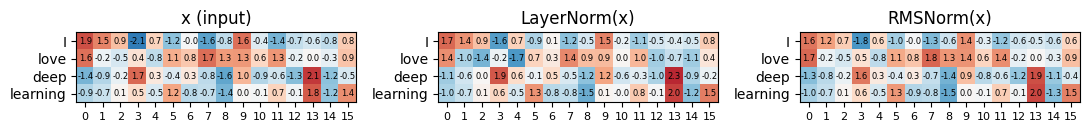

Row means  (raw): [-0.13672925531864166, 0.572855532169342, -0.26582637429237366, -0.0390036478638649]
Row means  (LN ): [-2.421438694000244e-08, 7.450580596923828e-09, -4.470348358154297e-08, 7.450580596923828e-09]   <- driven to 0
Row means  (RMS): [-0.11366008222103119, 0.5977362394332886, -0.24332648515701294, -0.042347609996795654]   <- *not* zeroed

Row RMS    (raw): [1.2029662132263184, 0.958375096321106, 1.0924679040908813, 0.9210349321365356]
Row RMS    (LN ): [0.999996542930603, 0.9999914765357971, 0.9999954700469971, 0.9999940395355225]
Row RMS    (RMS): [1.0000001192092896, 1.0, 1.0, 1.0]


In [3]:
from rmsnorm import RMSNorm

ln = nn.LayerNorm(d_model)
rn = RMSNorm(d_model)

x = x_anchor.clone()
y_ln  = ln(x)
y_rms = rn(x)

# Stack the three matrices for a side-by-side heatmap
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
for ax, mat, title in zip(axes, [x[0], y_ln[0].detach(), y_rms[0].detach()],
                          ["x (input)", "LayerNorm(x)", "RMSNorm(x)"]):
    im = ax.imshow(mat.numpy(), cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_yticks(range(T)); ax.set_yticklabels(TOKENS)
    ax.set_xticks(range(d_model)); ax.set_xticklabels(range(d_model), fontsize=8)
    ax.set_title(title)
    for i in range(T):
        for j in range(d_model):
            ax.text(j, i, f"{mat[i,j].item():.1f}", ha="center", va="center", fontsize=6)
plt.tight_layout(); plt.show()

print("Row means  (raw):", x[0].mean(dim=-1).tolist())
print("Row means  (LN ):", y_ln[0].mean(dim=-1).detach().tolist(),  "  <- driven to 0")
print("Row means  (RMS):", y_rms[0].mean(dim=-1).detach().tolist(), "  <- *not* zeroed")
print()
print("Row RMS    (raw):", x[0].pow(2).mean(dim=-1).sqrt().tolist())
print("Row RMS    (LN ):", y_ln[0].pow(2).mean(dim=-1).sqrt().detach().tolist())
print("Row RMS    (RMS):", y_rms[0].pow(2).mean(dim=-1).sqrt().detach().tolist())


### Do the leveler's math by hand

Let's prove the volume-setting is nothing fancy. Take the first word *I*, call its 16 numbers `x_0`. The "typical size" is just the root-mean-square (square them, average, square-root), and then we divide by it and apply the learned gain `g`:

$$\text{typical size}(x_0) = \sqrt{\tfrac{1}{16}\sum_{j} x_{0j}^2 + \varepsilon} \quad\Rightarrow\quad y_0 = \frac{x_0}{\text{typical size}} \cdot g$$

We compute it ourselves and check it matches the module exactly.


In [4]:
x0 = x_anchor[0, 0]                         # (d_model,)
rms_manual = (x0.pow(2).mean() + 1e-8).sqrt()
y0_manual  = x0 / rms_manual * rn.weight

print("rms(x_0)    manually   :", rms_manual.item())
print("RMSNorm(x_0) manually  :", y0_manual.detach().numpy())
print("RMSNorm(x_0) module    :", y_rms[0, 0].detach().numpy())
print("max abs diff           :", (y0_manual - y_rms[0, 0]).abs().max().item())


rms(x_0)    manually   : 1.2029662132263184
RMSNorm(x_0) manually  : [ 1.602  1.236  0.749 -1.75   0.564 -1.026 -0.036 -1.334 -0.625  1.371
 -0.326 -1.167 -0.605 -0.465 -0.639  0.634]
RMSNorm(x_0) module    : [ 1.602  1.236  0.749 -1.75   0.564 -1.026 -0.036 -1.334 -0.625  1.371
 -0.326 -1.167 -0.605 -0.465 -0.639  0.634]
max abs diff           : 0.0


### Shape trace

| Stage | Shape |
|---|---|
| input `x` | `(B, T, d_model)` = `(1, 4, 16)` |
| `x.pow(2).mean(dim=-1, keepdim=True)` | `(1, 4, 1)` |
| `r = sqrt(... + eps)` | `(1, 4, 1)` |
| `(x / r) * weight` | `(1, 4, 16)` |
| `weight` (learned gain) | `(d_model,)` = `(16,)` |

### Why dropping those steps is safe (simple to deep)

- **Simple:** fewer steps = faster. Skipping the re-centering removes a whole pass over the numbers, every word, every layer.
- **Practical:** the extra add-on (bias) is redundant — the very next layer can absorb whatever it would have done.
- **Deeper:** re-centering was meant to keep signals well-behaved, but the residual "shortcut" connections (from Part 1) already do that job. With those in place, the centering was quietly doing almost nothing — so removing it costs no real quality.

**In one line:** RMSNorm is LayerNorm with the parts removed that only looked important on paper.


---
## 3.2 Stamping Each Word With Its Position (RoPE)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#e8e8e8,stroke:#bbb,color:#777
    style attn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style rms2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

(The map highlights **attention** because this upgrade lives *inside* attention now — there's no separate position step anymore.)

### What we're upgrading, and why

Attention, on its own, treats the words as an unordered pile — it literally can't tell "dog bites man" from "man bites dog." So we have to tell every word *where it sits*.

Part 1 did this by **adding** a little position vector to each word at the very start. RoPE does something cleverer: it **rotates** each word's vector by an angle that depends on its position — like setting the hand of a clock. Word 0 → no turn, word 1 → a small turn, word 2 → a bigger turn, and so on.

Here's the payoff. When attention compares two words (by a dot product), the result of comparing two *rotated* vectors depends only on the **difference** between their angles — that is, on **how far apart** the two words are. So the model naturally feels "3 words back" rather than memorizing fixed positions — and it keeps working even on text longer than anything it was trained on.

### The formula behind it (optional)

Split each word-vector into **pairs** of numbers. Each pair gets its own clock that ticks at its own speed (`inv_freq`). At position `p`, pair `i` is turned by angle:

$$\theta = p \cdot \text{inv\_freq}[i]$$

and "turning a pair" is the standard 2D rotation:

$$\begin{pmatrix} x'_{2i} \\ x'_{2i+1} \end{pmatrix} = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix} \begin{pmatrix} x_{2i} \\ x_{2i+1} \end{pmatrix}$$

Fast clocks (early pairs) notice small position changes; slow clocks (later pairs) track long-range structure. Together they give every position its own unique "time on the dial."

### Picture 1: the clock dials (cos / sin tables)


cos shape: (16, 4)   sin shape: (16, 4)


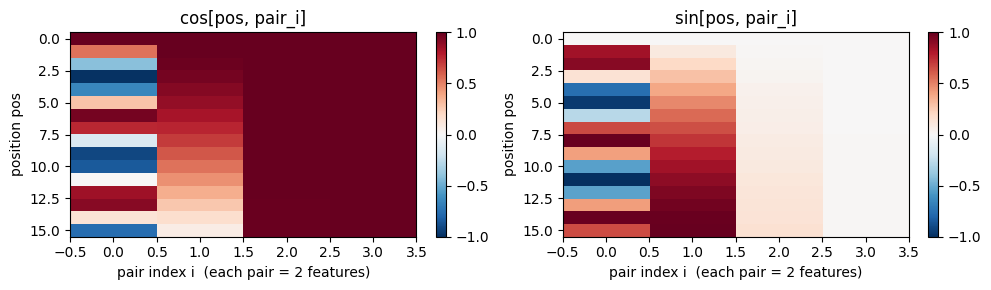

In [5]:
from rope_custom import RoPECache, apply_rope_single

# Use a slightly larger head_dim here so the visualization has more pairs.
HEAD_DIM_VIZ = 8
MAX_POS_VIZ  = 16

rc = RoPECache(head_dim=HEAD_DIM_VIZ, max_pos=MAX_POS_VIZ)
print("cos shape:", tuple(rc.cos.shape), "  sin shape:", tuple(rc.sin.shape))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, mat, title in zip(axes, [rc.cos.numpy(), rc.sin.numpy()],
                          ["cos[pos, pair_i]", "sin[pos, pair_i]"]):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xlabel("pair index i  (each pair = 2 features)")
    ax.set_ylabel("position pos")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


**What you see:** later pairs (toward the right) change more slowly as you move down the position axis — those are the "slow clocks." Early pairs change fast. Different speeds = each position gets a distinct combined reading.

### Picture 2: one pair turning like a clock hand

Take a single pair of numbers and watch RoPE rotate it as the word moves through positions `p = 0, 1, 2, 3, 4`. A pair is just a point in 2D, so we can literally draw the hand sweeping around.


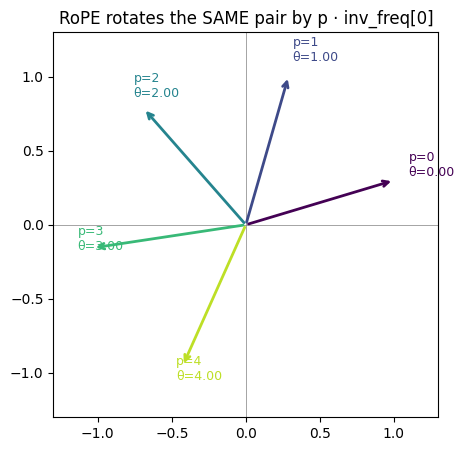

In [6]:
# A single pair (x0, x1) -- pick something off-axis for visibility
pair = torch.tensor([1.0, 0.3])

inv_freq_0 = 1.0 / 10000 ** (0 / HEAD_DIM_VIZ)   # for the i=0 (fastest) pair
positions = list(range(5))

fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(positions)))
for p, c in zip(positions, colors):
    theta = p * inv_freq_0
    rot = torch.tensor([[math.cos(theta), -math.sin(theta)],
                        [math.sin(theta),  math.cos(theta)]])
    vec = rot @ pair
    ax.annotate("", xy=(vec[0], vec[1]), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vec[0]*1.1, vec[1]*1.1, f"p={p}\n\u03B8={theta:.2f}", color=c, fontsize=9)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect("equal")
ax.set_title("RoPE rotates the SAME pair by p \u00B7 inv_freq[0]")
plt.show()


**What you see:** the same starting hand gets turned further the later the position — exactly the "set the dial by position" idea. Each position lands at its own angle.

### Picture 3: why comparing two words only feels the *distance* between them

This is the magic. If we rotate two words by their positions and then compare them (dot product), the score depends *only* on the gap between their positions — not where they sit absolutely. Let's confirm it with numbers.


In [7]:
# Pick a fixed Q and K (with small head_dim and one head for clarity)
torch.manual_seed(0)
q = torch.randn(1, 1, 1, HEAD_DIM_VIZ)   # (B,H,T=1,D)
k = torch.randn(1, 1, 1, HEAD_DIM_VIZ)

def rotated_dot(p, q_pos):
    """Apply RoPE at position p to q, at position q_pos to k, then return the dot product."""
    cos_p, sin_p = rc.get(torch.tensor([p]))
    cos_q, sin_q = rc.get(torch.tensor([q_pos]))
    qr = apply_rope_single(q, cos_p, sin_p)
    kr = apply_rope_single(k, cos_q, sin_q)
    return (qr * kr).sum().item()

# Two settings with the SAME relative offset of +3 should give the same dot product
print("dot(p=0, q=3):", rotated_dot(0, 3))
print("dot(p=2, q=5):", rotated_dot(2, 5))
print("dot(p=7, q=10):", rotated_dot(7, 10))
print()
# Different relative offsets give different dot products
for rel in [0, 1, 2, 4, 8, 12]:
    print(f"relative offset = {rel:2d}  ->  dot = {rotated_dot(0, rel):+.4f}")


dot(p=0, q=3): 1.5850569009780884
dot(p=2, q=5): 1.5850571393966675
dot(p=7, q=10): 1.5850569009780884

relative offset =  0  ->  dot = -0.5261
relative offset =  1  ->  dot = +0.6514
relative offset =  2  ->  dot = +1.6625
relative offset =  4  ->  dot = +0.4849
relative offset =  8  ->  dot = +1.2329
relative offset = 12  ->  dot = -1.3802


**What you see:** the first three numbers are identical — same gap (+3) between the two words, even though they sit at different absolute spots. The second list shows different gaps give different scores. *That* is the position signal: the model feels the distance, not the address.

### Set two clock hands by hand

Let's compute a couple of angles ourselves. The fast clock (`pair 0`) ticks once per position; the slower clock (`pair 2`) ticks a tenth as fast. At position `p = 2`:

$$\theta_{\text{pair }0} = 2 \cdot 1 = 2.0 \;\Rightarrow\; \cos \approx -0.416,\ \sin \approx 0.909$$

$$\theta_{\text{pair }2} = 2 \cdot 0.1 = 0.2 \;\Rightarrow\; \cos \approx 0.980,\ \sin \approx 0.199$$


In [8]:
# Sanity-check the hand calculation against the cache
cos2, sin2 = rc.get(torch.tensor([2]))   # at position 2
print("cos(theta_{0,2}):  manual=-0.416   from cache:", cos2[0, 0].item())
print("sin(theta_{0,2}):  manual= 0.909   from cache:", sin2[0, 0].item())
print()
print("cos(theta_{2,2}):  manual= 0.980   from cache:", cos2[0, 1].item())
print("sin(theta_{2,2}):  manual= 0.199   from cache:", sin2[0, 1].item())


cos(theta_{0,2}):  manual=-0.416   from cache: -0.416146844625473
sin(theta_{0,2}):  manual= 0.909   from cache: 0.9092974066734314

cos(theta_{2,2}):  manual= 0.980   from cache: 0.9800665974617004
sin(theta_{2,2}):  manual= 0.199   from cache: 0.19866932928562164


### Why both sin *and* cos? (simple to deep)

- **Simple:** sin and cos together are just what "turn the dial by an angle" means — you need both to describe a rotation. Drop one and it's no longer a clean turn.
- **Practical:** the pair `(cos, sin)` plus many clocks at different speeds gives every position its own unmistakable reading — the same trick Part 1's position vectors used, just applied as a rotation.
- **Deeper:** because turning the dial is a clean, reversible operation, the comparison that attention does naturally cancels out the absolute positions and leaves only the *gap* between words — exactly the "how far apart" signal attention wants.

**In one line:** rotating by position means comparing two words only feels the *distance* between them — which is the thing that actually matters.

### Shape trace

| Stage | Shape |
|---|---|
| `inv_freq` | `(D/2,)` |
| `cos`, `sin` table | `(max_pos, D/2)` |
| slice for current positions | `(T, D/2)` |
| input `q` (or `k`) | `(B, H, T, D)` |
| `cos.unsqueeze(0).unsqueeze(0)` | `(1, 1, T, D/2)` |
| pair split: `q[..., ::2]`, `q[..., 1::2]` | each `(B, H, T, D/2)` |
| `xr1 = x1*cos - x2*sin`, `xr2 = x1*sin + x2*cos` | each `(B, H, T, D/2)` |
| interleaved output | `(B, H, T, D)` |

### Compare with the .py file


In [9]:
# Verify our hand-rolled understanding against the actual module behavior.
# Apply RoPE at start_pos=0 to a small q and confirm the shape and that values changed.
q_small = torch.randn(1, 2, T, d_head)   # d_head=4 already even -> good for RoPE
cos_small, sin_small = RoPECache(head_dim=d_head, max_pos=64).get(torch.arange(T))
q_rot = apply_rope_single(q_small, cos_small, sin_small)
print("input  q :", tuple(q_small.shape))
print("output qr:", tuple(q_rot.shape))
print("changed? ", not torch.allclose(q_small, q_rot))


input  q : (1, 2, 4, 4)
output qr: (1, 2, 4, 4)
changed?  True


---
## 3.3 A Smart Dimmer on Each Wire (SwiGLU)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#e8e8e8,stroke:#bbb,color:#777
    style attn fill:#e8e8e8,stroke:#bbb,color:#777
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style rms2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're upgrading, and why

After looking at its neighbours, each word does some private "thinking" in the feed-forward step. Part 1's version was a plain pipe: push the word through, apply one fixed filter, push it out — every word treated the same way.

SwiGLU adds a **dimmer switch**. It runs two wires in parallel: one carries the *signal* (the candidate thought), and the other is a **gate** that decides, feature by feature, *how much of that signal to let through* — and the gate's setting depends on the word itself. So instead of one fixed filter for everyone, each word turns its own dimmers up or down.

### The formula behind it (optional)

$$\text{SwiGLU}(x) = \big( \underbrace{(x W_1)}_{\text{signal}} \;\odot\; \underbrace{\text{SiLU}(x W_2)}_{\text{dimmer}} \big) W_3$$

- the **signal** wire carries the candidate values
- the **dimmer** wire is a smooth knob (SiLU) per feature that scales the signal up or down
- multiply the two, then project back down with `W_3`

**In one line:** Part 1's filter was one fixed setting for every word; SwiGLU lets each word set its own dimmers — a learned knob instead of a fixed one.

### Picture: the two smooth knobs (SiLU vs GELU) side by side


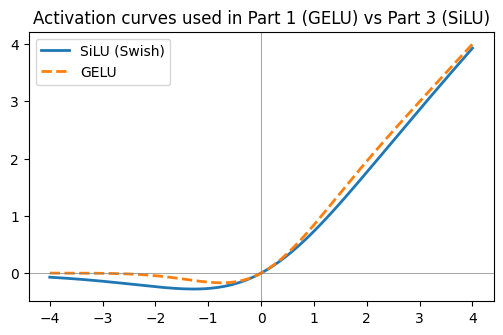

Both look almost identical -> the win comes from gating, not the activation choice.


In [10]:
from swiglu import SwiGLU

zs = torch.linspace(-4, 4, 200)
silu = F.silu(zs)
gelu = F.gelu(zs)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(zs.numpy(), silu.numpy(), label="SiLU (Swish)", lw=2)
ax.plot(zs.numpy(), gelu.numpy(), label="GELU", lw=2, ls="--")
ax.axhline(0, color="grey", lw=0.5); ax.axvline(0, color="grey", lw=0.5)
ax.set_title("Activation curves used in Part 1 (GELU) vs Part 3 (SiLU)")
ax.legend(); plt.show()
print("Both look almost identical -> the win comes from gating, not the activation choice.")


### Picture: the dimmer settings for our sentence

We push our four words through SwiGLU and show the **dimmer** wire `b` — so you can literally see each word choosing different settings.


a shape : (1, 4, 64)
b shape : (1, 4, 64)
y shape : (1, 4, 16)


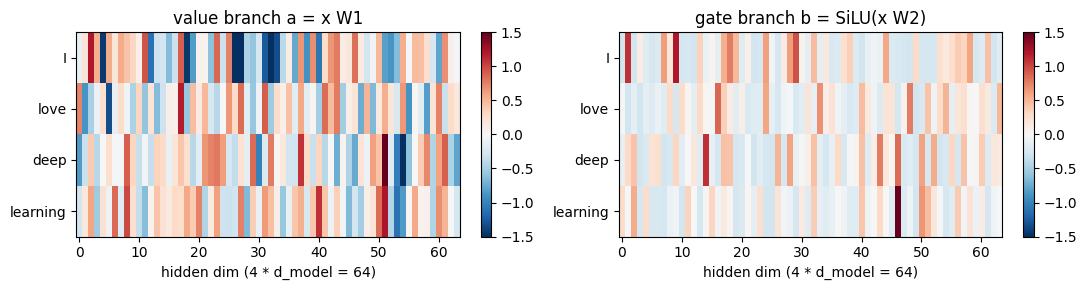

In [11]:
ffn = SwiGLU(dim=d_model, mult=4, dropout=0.0)
ffn.eval()

# Manually compute the gate so we can plot it
with torch.no_grad():
    a = ffn.w1(x_anchor)            # (B,T,4d)
    b = ffn.act(ffn.w2(x_anchor))   # (B,T,4d)
    y = ffn(x_anchor)               # (B,T,d)

print("a shape :", tuple(a.shape))
print("b shape :", tuple(b.shape))
print("y shape :", tuple(y.shape))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
for ax, mat, title in zip(axes, [a[0].numpy(), b[0].numpy()],
                          ["value branch a = x W1", "gate branch b = SiLU(x W2)"]):
    im = ax.imshow(mat, cmap="RdBu_r", aspect="auto", vmin=-1.5, vmax=1.5)
    ax.set_yticks(range(T)); ax.set_yticklabels(TOKENS)
    ax.set_xlabel("hidden dim (4 * d_model = 64)")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


**What you see:** the dimmer settings differ from row to row — each word amplifies some features and dims others. A fixed filter (Part 1) could never do that.

### Shape trace

| Stage | Shape |
|---|---|
| input `x` | `(B, T, d_model)` |
| `a = x W1` | `(B, T, 4*d_model)` |
| `b = SiLU(x W2)` | `(B, T, 4*d_model)` |
| `a * b` | `(B, T, 4*d_model)` |
| `(a * b) W3` | `(B, T, d_model)` |

### Param count

| Matrix | Shape | # params (mult=4) |
|---|---|---|
| W1 | `(d, 4d)` | $4 d^2$ |
| W2 | `(d, 4d)` | $4 d^2$ |
| W3 | `(4d, d)` | $4 d^2$ |
| total | | $\mathbf{12 d^2}$ |

The old GELU version uses two weight matrices ($8d^2$); SwiGLU's three make it ~50% heavier — so recipes often shrink the hidden size a bit to keep the total even.

### Why the dimmer helps (simple to deep)

- **Simple:** the dimmer is set *per word, per feature* — a single fixed filter can't be that flexible.
- **Practical:** at the same size, SwiGLU reliably trains to a lower loss, especially as models get big — which is why modern LLMs use it.
- **Deeper:** multiplying two learned wires together lets the network express richer "if this feature, then scale that one" interactions than a plain pipe ever could, for roughly the same number of knobs.

**In one line:** the old feed-forward was a fixed filter; SwiGLU is a learned, content-aware dimmer.

### Check against the real `.py`


In [12]:
# Use the actual module on x_anchor and confirm shape preservation.
y2 = ffn(x_anchor)
print("input :", tuple(x_anchor.shape))
print("output:", tuple(y2.shape))


input : (1, 4, 16)
output: (1, 4, 16)


---
## 3.4 Taking Notes Instead of Re-Reading (KV cache)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#e8e8e8,stroke:#bbb,color:#777
    style attn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style rms2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

(The map highlights **attention** because the note-taking happens inside it.)

### What we're upgrading, and why

When the model writes text, it produces **one word at a time**, and each new word has to look back at everything written so far. The naive way is exhausting: for every single new word, re-read the *entire* story from the beginning. Write a 1000-word story and you've re-read the opening line 1000 times.

A person would never do that — they'd **take notes**. The first time you read each word, you jot down its two "summary cards" (called the **key** and **value**). For the next word, you just glance at the saved notes instead of re-reading the whole text. That's the **KV cache**, and it turns slow, ballooning work into quick, steady work.

One more issue: on a *very* long story the notebook itself gets huge. So **RollingKV** keeps the notebook bounded — hang on to the **last few** notes (recent context) plus the **first few** (more on why those matter in a moment).

### The bookkeeping (optional)

- each step, compute the new word's two cards and **append** them to the notebook
- once the notebook is longer than `window + sink`, **crop** it down to: the first `sink` notes ++ the most recent `window` notes

That's the whole data structure — an append-and-occasionally-trim list of notes.

### Picture: how big the notebook gets, step by step


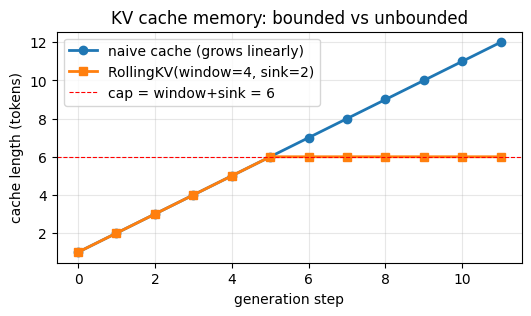

In [13]:
from kv_cache import RollingKV

window = 4
sink   = 2
rk = RollingKV(window=window, sink=sink)

# Run 12 fake steps and track cache length
unbounded = []
bounded   = []
for step in range(12):
    k_new = torch.randn(1, 2, 1, d_head)
    v_new = torch.randn(1, 2, 1, d_head)
    k, v = rk.step(k_new, v_new)
    unbounded.append(step + 1)              # what the cache *would* be without rolling
    bounded.append(k.size(2))               # what RollingKV actually keeps

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(unbounded, label="naive cache (grows linearly)", marker="o", lw=2)
ax.plot(bounded,   label=f"RollingKV(window={window}, sink={sink})", marker="s", lw=2)
ax.axhline(window + sink, color="red", ls="--", lw=0.8, label=f"cap = window+sink = {window+sink}")
ax.set_xlabel("generation step"); ax.set_ylabel("cache length (tokens)")
ax.set_title("KV cache memory: bounded vs unbounded")
ax.legend(); ax.grid(True, alpha=0.3); plt.show()


**What you see:** the note-taking notebook (orange) levels off at `window + sink = 6` and stays there, while the naive "keep everything" notebook (blue) just grows and grows.

### Picture: which notes survive each trim?


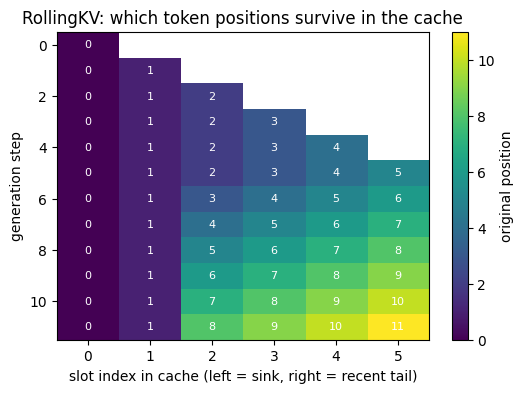

In [14]:
# Restart and record the position indices kept in the cache after each step.
rk = RollingKV(window=window, sink=sink)
kept = []
for step in range(12):
    k_new = torch.full((1, 2, 1, d_head), float(step))   # mark with the step number
    v_new = torch.full((1, 2, 1, d_head), float(step))
    k, v = rk.step(k_new, v_new)
    # Each entry's first feature value tells us which step it was added at
    positions = k[0, 0, :, 0].tolist()
    kept.append([int(p) for p in positions])

# Build a (T_steps, max_keep) "kept positions" image
T_steps = len(kept)
max_keep = window + sink
img = np.full((T_steps, max_keep), np.nan)
for i, row in enumerate(kept):
    for j, p in enumerate(row):
        img[i, j] = p

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(img, cmap="viridis", aspect="auto")
ax.set_xlabel("slot index in cache (left = sink, right = recent tail)")
ax.set_ylabel("generation step")
ax.set_title("RollingKV: which token positions survive in the cache")
for i in range(T_steps):
    for j in range(max_keep):
        if not np.isnan(img[i, j]):
            ax.text(j, i, f"{int(img[i,j])}", ha="center", va="center", color="white", fontsize=8)
plt.colorbar(im, ax=ax, label="original position"); plt.show()


**What you see:** the leftmost two columns are *frozen* on the very first words (positions 0 and 1) — those are the **"anchor" notes**. The rest of the columns slide forward to follow the four most recent words.

### Why keep the first few notes ("the anchor")? (simple to deep)

- **Simple:** the opening words soak up a surprising amount of every later word's attention. Throw them away and later words lose their footing and the output degrades.
- **Practical:** experiments found that *just* keeping the first handful of notes is enough to keep quality steady during very long generation — a tiny, cheap fix.
- **Deeper:** attention always has to "spend" its focus somewhere; when a word has nothing especially relevant to look at, it parks that leftover focus on the first words, which act as a stable anchor. Crop those away and the parked focus has nowhere sensible to land — so the layer wobbles.

**In one line:** the notebook is the real bottleneck for long text — keeping recent notes plus a few anchor notes keeps it small *without* hurting quality.

### Shape trace

| Stage | Shape |
|---|---|
| K, V at step `t`           | `(B, n_kv_head, t, d_head)` |
| `k_new, v_new`             | `(B, n_kv_head, 1, d_head)` |
| after concat               | `(B, n_kv_head, t+1, d_head)` |
| after RollingKV crop       | `(B, n_kv_head, ≤ window+sink, d_head)` |


---
## 3.5 Sharing the Notes (Modern Attention + GQA)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#e8e8e8,stroke:#bbb,color:#777
    style attn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add1 fill:#e8e8e8,stroke:#bbb,color:#777
    style rms2 fill:#e8e8e8,stroke:#bbb,color:#777
    style ffn fill:#e8e8e8,stroke:#bbb,color:#777
    style add2 fill:#e8e8e8,stroke:#bbb,color:#777
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

### What we're upgrading, and why

This section bolts together the upgrades — RoPE (3.2), the note-taking cache (3.4) — into one modern attention part. The genuinely *new* idea here is **GQA (Grouped-Query Attention)**, and it's about sharing.

Think of attention as a room of **readers** (the "query heads"), each looking for something different. In Part 1, every reader kept their **own private copy** of the notes (their own key/value cards). That's a lot of duplicate notebooks to store and — worse — to haul around every single step while generating.

GQA fixes the waste: small **groups of readers share one set of notes**. Four readers, but only two shared notebooks — each notebook used by two readers. Why does this matter so much? During generation the slow part isn't the thinking, it's *carrying those notebooks back and forth from memory*. Halve the notebooks and you roughly halve that cost — with almost no drop in quality.

### Three ways to share, in one table

| Setup | readers | notebooks | sharing |
|---|---|---|---|
| Part 1 (every reader their own) | 4 | 4 | nobody shares |
| extreme sharing | 4 | 1 | everyone shares one |
| **GQA (the sweet spot)** | 4 | **2** | each notebook shared by 2 readers |

### Picture: who shares with whom (4 readers, 2 notebooks)


```mermaid
graph TD
    subgraph Queries
      q0["Q head 0"]
      q1["Q head 1"]
      q2["Q head 2"]
      q3["Q head 3"]
    end
    subgraph KV
      kv0["KV head 0"]
      kv1["KV head 1"]
    end
    q0 --> kv0
    q1 --> kv0
    q2 --> kv1
    q3 --> kv1
    style q0 fill:#d6eaf8,stroke:#2874a6,color:#000
    style q1 fill:#d6eaf8,stroke:#2874a6,color:#000
    style q2 fill:#fdebd0,stroke:#b35900,color:#000
    style q3 fill:#fdebd0,stroke:#b35900,color:#000
    style kv0 fill:#d6eaf8,stroke:#2874a6,stroke-width:3px,color:#000
    style kv1 fill:#fdebd0,stroke:#b35900,stroke-width:3px,color:#000
```

Readers 0 and 1 share notebook 0 (blue); readers 2 and 3 share notebook 1 (orange). When it's actually time to read, we hand each reader a copy of its shared notebook — but the **stored** notebook count stays at 2, which is what saves the memory (~50% here).

### Shape trace through one forward pass (B=1, T=4, no cache)

| Stage | Shape |
|---|---|
| input `x`             | `(1, 4, 16)` |
| `Wq(x)`               | `(1, 4, 16)`  = `(B, T, n_head*d_head)` |
| `Wk(x)`, `Wv(x)`      | `(1, 4, 8)`   = `(B, T, n_kv_head*d_head)` |
| `q.view + transpose`  | `(1, 4, 4, 4)`  = `(B, n_head, T, d_head)` |
| `k,v.view + transpose`| `(1, 2, 4, 4)`  = `(B, n_kv_head, T, d_head)` |
| RoPE applied to q, k  | same shapes |
| `repeat_interleave(2)`| `(1, 4, 4, 4)`  expanded to match Q heads |
| sdpa output           | `(1, 4, 4, 4)` |
| merge heads           | `(1, 4, 16)` |
| `Wo(...)`             | `(1, 4, 16)` |


### Run our sentence through the modern attention part


In [15]:
from attn_modern import CausalSelfAttentionModern

attn = CausalSelfAttentionModern(
    n_embd=d_model,
    n_head=n_head,
    n_kv_head=n_kv_head,
    rope=True,
    max_pos=64,
)
attn.eval()

with torch.no_grad():
    y, kv = attn(x_anchor, kv_cache=None, start_pos=0)

print("input  x  :", tuple(x_anchor.shape))
print("output y  :", tuple(y.shape))
print("KV cache K:", tuple(kv.k.shape), "  (note: only n_kv_head =", n_kv_head, "K heads)")
print("KV cache V:", tuple(kv.v.shape))


input  x  : (1, 4, 16)
output y  : (1, 4, 16)
KV cache K: (1, 2, 4, 4)   (note: only n_kv_head = 2 K heads)
KV cache V: (1, 2, 4, 4)


### One generation step: hand it the notebook + a single new word


In [16]:
# Now pretend we're generating. Feed in just one new token (T=1) with the cache from above.
new_token = torch.randn(B, 1, d_model)

with torch.no_grad():
    y2, kv2 = attn(new_token, kv_cache=kv, start_pos=T)   # start_pos = T because we already saw T tokens

print("new input shape   :", tuple(new_token.shape))
print("output shape      :", tuple(y2.shape))
print("KV cache K shape  :", tuple(kv2.k.shape), " (grew from", kv.k.size(2), "to", kv2.k.size(2), "tokens)")


new input shape   : (1, 1, 16)
output shape      : (1, 1, 16)
KV cache K shape  : (1, 2, 5, 4)  (grew from 4 to 5 tokens)


### The bounded notebook, live

Let's run a longer pretend generation and watch the notebook stop growing once we turn on the recent-window and anchor settings.


In [17]:
attn_bounded = CausalSelfAttentionModern(
    n_embd=d_model,
    n_head=n_head,
    n_kv_head=n_kv_head,
    rope=True,
    max_pos=64,
    sliding_window=4,
    attention_sink=2,
)
attn_bounded.eval()

# Prime with the anchor sentence
with torch.no_grad():
    _, kv = attn_bounded(x_anchor, kv_cache=None, start_pos=0)
print(f"after priming with T={T:2d} tokens, cache len = {kv.k.size(2)}")

# Generate 10 more, single tokens at a time
with torch.no_grad():
    for step in range(10):
        nt = torch.randn(B, 1, d_model)
        _, kv = attn_bounded(nt, kv_cache=kv, start_pos=T+step)
        print(f"after step {step+1:2d}, cache len = {kv.k.size(2)}  (bounded by {attn_bounded.sliding_window + attn_bounded.attention_sink})")


after priming with T= 4 tokens, cache len = 4
after step  1, cache len = 5  (bounded by 6)
after step  2, cache len = 6  (bounded by 6)
after step  3, cache len = 7  (bounded by 6)
after step  4, cache len = 8  (bounded by 6)
after step  5, cache len = 9  (bounded by 6)
after step  6, cache len = 10  (bounded by 6)
after step  7, cache len = 11  (bounded by 6)
after step  8, cache len = 12  (bounded by 6)
after step  9, cache len = 13  (bounded by 6)
after step 10, cache len = 14  (bounded by 6)


**What you see:** once the notebook passes `window + sink = 6`, it stops growing — the same bounded behaviour we saw in 3.4, now happening inside real attention.

### Check against the real `.py`

Open `attn_modern.py`. Its forward pass is exactly the story we just told:
1. give the readers their query, and make the (fewer) shared notebooks — keys and values
2. stamp positions onto query & keys with RoPE (3.2)
3. tack the new notes onto the saved notebook (3.4)
4. trim to anchor + recent window (3.4)
5. hand each reader a copy of its shared notebook (the GQA step)
6. let the readers read (the actual attention)
7. merge the readers' findings and project out


---
## 3.6 Bolting the Upgraded Parts Back Together (Modern Block)

```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style attn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add1 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style rms2 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ffn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add2 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

The whole block is lit up now — every part is its upgraded version.

### What we're doing here, and why

Here's the satisfying part: the **shape of the block never changed.** It's the exact same wiring as Part 1 — balance, look around, add the result back via a shortcut, balance again, think, add back again — we just dropped the modern parts into their slots. So this section is really a quick sanity check: same in-and-out shape (so blocks still stack), and a look at the part count.

### The whole block in two lines (optional)

$$x \leftarrow x + \text{ModernAttention}(\text{RMSNorm}(x)) \quad\text{(look around, add back)}$$
$$x \leftarrow x + \text{SwiGLU}(\text{RMSNorm}(x)) \quad\text{(think, add back)}$$

The `x + ...` is the **shortcut** (residual) from Part 1 — it lets the original signal skip straight through, which keeps deep stacks trainable.


In [18]:
from block_modern import TransformerBlockModern

block = TransformerBlockModern(
    n_embd=d_model,
    n_head=n_head,
    n_kv_head=n_kv_head,
    use_rmsnorm=True,
    use_swiglu=True,
    rope=True,
    max_pos=64,
)
block.eval()

with torch.no_grad():
    y, kv = block(x_anchor, kv_cache=None, start_pos=0)

print("input  x :", tuple(x_anchor.shape))
print("output y :", tuple(y.shape))
print("KV cache :", tuple(kv.k.shape), "k", tuple(kv.v.shape), "v")

# Param count
total = sum(p.numel() for p in block.parameters())
by_name = {n: p.numel() for n, p in block.named_parameters()}
print()
print(f"Total params in this block: {total:,}")
for name, n in by_name.items():
    print(f"  {name:30s} -> {n:6,}")


input  x : (1, 4, 16)
output y : (1, 4, 16)
KV cache : (1, 2, 4, 4) k (1, 2, 4, 4) v

Total params in this block: 3,872
  ln1.weight                     ->     16
  attn.wq.weight                 ->    256
  attn.wk.weight                 ->    128
  attn.wv.weight                 ->    128
  attn.proj.weight               ->    256
  ln2.weight                     ->     16
  ffn.w1.weight                  ->  1,024
  ffn.w2.weight                  ->  1,024
  ffn.w3.weight                  ->  1,024


### Shape trace

| Stage | Shape |
|---|---|
| input `x`                       | `(B, T, d_model)` |
| `ln1(x)` (RMSNorm)              | `(B, T, d_model)` |
| `attn(...)`                     | `(B, T, d_model)` |
| `x + a` (residual 1)            | `(B, T, d_model)` |
| `ln2(x)` (RMSNorm)              | `(B, T, d_model)` |
| `ffn(...)` (SwiGLU)             | `(B, T, d_model)` |
| `x + ffn(...)` (residual 2)     | `(B, T, d_model)` |
| output                          | `(B, T, d_model)` |

### Check against the real `.py`

`block_modern.py` really is just those four lines — balance, look around + add back, balance + think + add back:
```python
a, kv_cache = self.attn(self.ln1(x), kv_cache=kv_cache, start_pos=start_pos)
x = x + a                              # look around, add back
x = x + self.ffn(self.ln2(x))          # think, add back
return x, kv_cache
```


---
## 3.7 The Finished Upgraded Model (GPTModern)

```mermaid
graph TD
    ids["Token IDs (B, T)"]
    tok["Token Embedding (B, T, d_model)"]
    blk1["Block 1 (3.6)"]
    blk2["Block 2 (3.6)"]
    blkN["Block N (3.6)"]
    lnf["ln_f (Identity if RMSNorm else LayerNorm)"]
    head["LM head (Linear d_model -> vocab)"]
    out["Logits (B, T, vocab)"]

    ids --> tok --> blk1 --> blk2 --> blkN --> lnf --> head --> out

    style ids fill:#d5f5e3,stroke:#28a745,stroke-width:2px,color:#000
    style tok fill:#d5f5e3,stroke:#28a745,stroke-width:2px,color:#000
    style blk1 fill:#fff3c4,stroke:#b38600,color:#000
    style blk2 fill:#fff3c4,stroke:#b38600,color:#000
    style blkN fill:#fff3c4,stroke:#b38600,color:#000
    style lnf fill:#d6eaf8,stroke:#2874a6,color:#000
    style head fill:#e8daef,stroke:#6c3483,color:#000
    style out fill:#fdebd0,stroke:#b35900,stroke-width:2px,color:#000
```

### What we're doing here, and why

All that's left is stacking N of these upgraded blocks, with a word-to-vector lookup at the bottom and a vector-to-next-word layer at the top. Notice there's **no separate position step** anymore — RoPE inside each attention layer already handles position. One nice payoff of the note-taking upgrade.

To show the note-taking actually pays off, the model ships **two ways to generate** the same text:

| Way | What it does | Speed |
|---|---|---|
| `generate` | **takes notes** (the KV cache) | fast, steady per word |
| `generate_nocache` | **re-reads every time** | slow, gets slower |

### Build a tiny model and run both


In [19]:
from model_modern import GPTModern
from tokenizer import ByteTokenizer

torch.manual_seed(0)
tok = ByteTokenizer()
model = GPTModern(
    vocab_size=tok.vocab_size,
    block_size=128,
    n_layer=2,
    n_head=4,
    n_embd=64,
    n_kv_head=2,
    use_rmsnorm=True,
    use_swiglu=True,
    rope=True,
    max_pos=4096,
    sliding_window=32,
    attention_sink=2,
)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f"GPTModern params: {n_params:,}")


GPTModern params: 155,904


### Same prompt, both ways — time them


In [20]:
import time

prompt = torch.tensor([[10, 72, 105]], dtype=torch.long)   # arbitrary 3 byte ids
N = 60

# Cached generation
t0 = time.time()
with torch.no_grad():
    out_cached = model.generate(prompt.clone(), max_new_tokens=N, temperature=0.0, top_k=50)
t_cached = time.time() - t0

# Nocache generation
t0 = time.time()
with torch.no_grad():
    out_nocache = model.generate_nocache(prompt.clone(), max_new_tokens=N, temperature=0.0, top_k=50)
t_nocache = time.time() - t0

print(f"cached  : {t_cached*1000:7.1f} ms   shape {tuple(out_cached.shape)}")
print(f"nocache : {t_nocache*1000:7.1f} ms   shape {tuple(out_nocache.shape)}")
print(f"speedup : {t_nocache / max(t_cached, 1e-9):.2f}x")


top ids: [[172, 1, 2, 3, 4, 5, 6, 7, 8, 9]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[61, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[123, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[136, 1, 2, 3, 4, 5, 6, 7, 8, 9]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[35, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[228, 1, 2, 3, 4, 5, 6, 7, 8, 9]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[120, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[83, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[16, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
top ids: [[14, 0, 1, 2, 3, 4, 5, 6, 7, 8]]
top vs: [[1.0, 0

(The text is gibberish — this model never trained. We're only comparing *speed* here, not quality.)

### Picture: how long each new word takes

Let's time every individual word as it's generated, with note-taking vs re-reading.


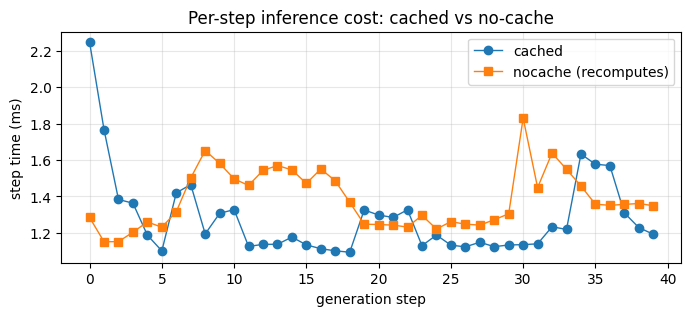

In [21]:
def time_per_step(generate_fn, N=40):
    times = []
    idx = prompt.clone()
    with torch.no_grad():
        kvs = [None] * len(model.blocks) if generate_fn == "cached" else None
        for step in range(N):
            t0 = time.time()
            if generate_fn == "cached":
                idx_cond = idx[:, -model.block_size:] if kvs[0] is None else idx[:, -1:]
                start_pos = 0 if kvs[0] is None else kvs[0].k.size(2)
                logits, _, kvs = model(idx_cond, kv_cache_list=kvs, start_pos=start_pos)
            else:
                idx_cond = idx[:, -model.block_size:]
                start_pos = idx.size(1) - idx_cond.size(1)
                logits, _, _ = model(idx_cond, kv_cache_list=None, start_pos=start_pos)
            next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            idx = torch.cat([idx, next_id], dim=1)
            times.append((time.time() - t0) * 1000.0)
    return times

t_cached_steps  = time_per_step("cached")
t_nocache_steps = time_per_step("nocache")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_cached_steps,  marker="o", label="cached", lw=1)
ax.plot(t_nocache_steps, marker="s", label="nocache (recomputes)", lw=1)
ax.set_xlabel("generation step"); ax.set_ylabel("step time (ms)")
ax.set_title("Per-step inference cost: cached vs no-cache")
ax.legend(); ax.grid(alpha=0.3); plt.show()


**What you see:**
- **re-reading** gets slower with every word — it re-reads more text each time — until it hits the window cap and levels off.
- **note-taking** stays roughly flat — each new word only does its own little bit of work plus a quick glance at the notes. That flat line is the whole reason real models can generate long text quickly.

### The finished upgrade, part by part
```mermaid
graph TD
    input["Input tokens<br>(B, T, d_model)"]
    rms1["3.1 RMSNorm 1"]
    attn["3.5 Modern Attention<br>RoPE + GQA + sliding window + sink + KV cache"]
    add1["+ residual"]
    rms2["3.1 RMSNorm 2"]
    ffn["3.3 SwiGLU FFN"]
    add2["+ residual"]
    output["Block output<br>(B, T, d_model)"]

    input --> rms1 --> attn --> add1
    input --> add1
    add1 --> rms2 --> ffn --> add2
    add1 --> add2
    add2 --> output

    style input fill:#e8e8e8,stroke:#bbb,color:#777
    style rms1 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style attn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add1 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style rms2 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style ffn fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style add2 fill:#d5f5e3,stroke:#28a745,stroke-width:3px,color:#000
    style output fill:#e8e8e8,stroke:#bbb,color:#777
```

Every part on the lift has now been swapped for its modern version. Quick recap of the upgrade shop:

- **3.1 RMSNorm** — a lighter audio leveler (set the volume, skip the re-centering).
- **3.2 RoPE** — stamp each word's position by *turning a dial*, so comparisons feel *distance*.
- **3.3 SwiGLU** — a per-word *dimmer switch* instead of one fixed filter.
- **3.4 KV cache** — *take notes* instead of re-reading; keep recent + anchor notes.
- **3.5 GQA** — readers *share* notebooks to save memory.
- **3.6 Modern block** — the same Part 1 wiring, with every part swapped in.
- **3.7 GPTModern** — stack the blocks; note-taking keeps generation fast.

You now have everything you need to read every file in `part_3/`:

- [rmsnorm.py](rmsnorm.py) — section 3.1
- [rope_custom.py](rope_custom.py) — section 3.2
- [swiglu.py](swiglu.py) — section 3.3
- [kv_cache.py](kv_cache.py) — section 3.4
- [attn_modern.py](attn_modern.py) — section 3.5
- [block_modern.py](block_modern.py) — section 3.6
- [model_modern.py](model_modern.py) — section 3.7
- [demo_generate.py](demo_generate.py) — runs the section 3.7 speed comparison as a script

### What's next

Part 4 takes this upgraded model and actually *teaches* it — the "coaching a student" notebook, with reading-in-chunks (BPE), flashcards, the warm-up/cool-down correction schedule, fast math, save points, and a progress chart. Every upgrade from this part carries straight over.
